In [158]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [159]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

import re
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MinMaxScaler

from scipy.sparse import csr_matrix, hstack

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

import scipy.stats as ss
from scipy.stats import pointbiserialr

import joblib

import seaborn as sns

from scipy.stats import chi2_contingency

import itertools

from pandas.api.types import is_numeric_dtype

from imblearn.over_sampling import SMOTE

In [160]:
ds = pd.read_csv('application_train.csv')

In [161]:
ds_test = pd.read_csv('application_test.csv')

In [162]:
ds.shape

(307511, 122)

In [163]:
# Percentage of missing values
(ds.isna().sum().sum() / ds.size) * 100

np.float64(24.39594190712943)

In [164]:
ds.keys()

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='str', length=122)

In [165]:
ds.dtypes.value_counts()

float64    65
int64      41
str        16
Name: count, dtype: int64

Pythonize columns

In [166]:
ds.columns = ds.columns.map(lambda x: x.lower())
ds.keys()

Index(['sk_id_curr', 'target', 'name_contract_type', 'code_gender',
       'flag_own_car', 'flag_own_realty', 'cnt_children', 'amt_income_total',
       'amt_credit', 'amt_annuity',
       ...
       'flag_document_18', 'flag_document_19', 'flag_document_20',
       'flag_document_21', 'amt_req_credit_bureau_hour',
       'amt_req_credit_bureau_day', 'amt_req_credit_bureau_week',
       'amt_req_credit_bureau_mon', 'amt_req_credit_bureau_qrt',
       'amt_req_credit_bureau_year'],
      dtype='str', length=122)

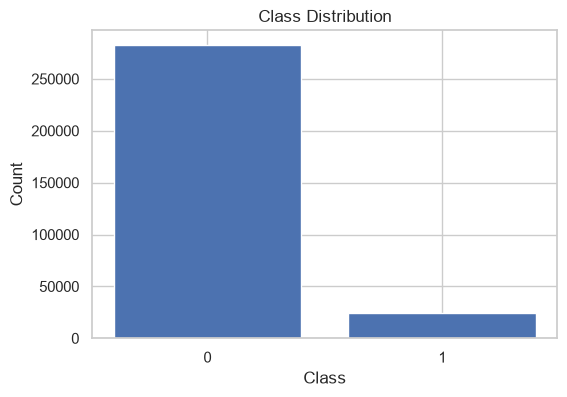

In [167]:
class_counts = ds.target.value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")

plt.savefig("class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [168]:
plt.savefig("class_distribution.pdf", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [169]:
ds.target.value_counts()

target
0    282686
1     24825
Name: count, dtype: int64

#### Some visualizations 

C:\Users\user\AppData\Local\Temp\ipykernel_25836\2079831930.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=missing_df, x='Column', y='Missing Values', palette='magma')


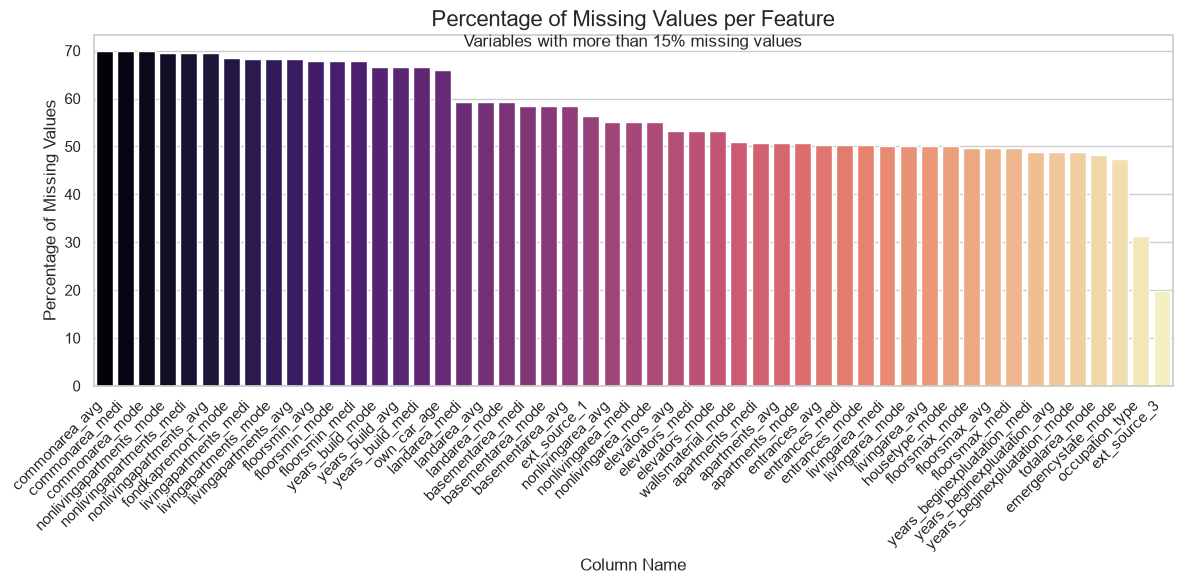

In [170]:
missing_values = ds.isnull().sum()
missing_values = (ds.isnull().sum() / len(ds)) * 100
missing_values = missing_values[missing_values > 15]

# Create a DataFrame for better control with seaborn
missing_df = missing_values.reset_index()
missing_df.columns = ['Column', 'Missing Values']
missing_df = missing_df.sort_values(by='Missing Values', ascending=False)

# Set seaborn style
sns.set_theme(style="whitegrid")

# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(data=missing_df, x='Column', y='Missing Values', palette='magma')

# Add title and rotate x-axis labels
plt.title('Percentage of Missing Values per Feature', fontsize=16)
plt.text(0.5, 1, 'Variables with more than 15% missing values', ha='center', va='top', fontsize=12, transform=plt.gca().transAxes)
plt.xlabel('Column Name', fontsize=12)
plt.ylabel('Percentage of Missing Values', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save to file
plt.savefig("percentage_missing_values.png")  # You can also use .pdf, .svg, .jpg

plt.show()

In [171]:
# Drop the SK_ID_CURR column from both datasets as it is just an identifier and not useful for modeling
ds = ds.drop(columns=["sk_id_curr"])
ds_test = ds_test.drop(columns=["SK_ID_CURR"])

In [172]:
ds.dtypes.value_counts()

float64    65
int64      40
str        16
Name: count, dtype: int64

### Explore correlations 

Note: Correlations between numeric variables and then correlations between categorical variables

#### Numeric variables

In [173]:
numeric_ds = ds.select_dtypes(include=['number'])
cat_ds = ds.select_dtypes(include=['object'])

C:\Users\user\AppData\Local\Temp\ipykernel_25836\3508541583.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_ds = ds.select_dtypes(include=['object'])


In [174]:
#Correlation of numeric variables with target
numeric_ds.corr()['target'].sort_values().head(15)

ext_source_3                 -0.178919
ext_source_2                 -0.160472
ext_source_1                 -0.155317
days_employed                -0.044932
floorsmax_avg                -0.044003
floorsmax_medi               -0.043768
floorsmax_mode               -0.043226
amt_goods_price              -0.039645
region_population_relative   -0.037227
elevators_avg                -0.034199
elevators_medi               -0.033863
floorsmin_avg                -0.033614
floorsmin_medi               -0.033394
livingarea_avg               -0.032997
livingarea_medi              -0.032739
Name: target, dtype: float64

In [175]:
numeric_ds.corr()['target'].sort_values().tail(15)

def_60_cnt_social_circle       0.031276
def_30_cnt_social_circle       0.032248
live_city_not_work_city        0.032518
own_car_age                    0.037612
days_registration              0.041975
flag_document_3                0.044346
reg_city_not_live_city         0.044395
flag_emp_phone                 0.045982
reg_city_not_work_city         0.050994
days_id_publish                0.051457
days_last_phone_change         0.055218
region_rating_client           0.058899
region_rating_client_w_city    0.060893
days_birth                     0.078239
target                         1.000000
Name: target, dtype: float64

##### Discussion
Obviously, all correlations between numerical variables and the target are small - none of them exceeds 0.2 in absolute value.

In [176]:
correlation_matrix = numeric_ds.corr(method="pearson")
print(correlation_matrix)

                              target  cnt_children  amt_income_total  \
target                      1.000000      0.019187         -0.003982   
cnt_children                0.019187      1.000000          0.012882   
amt_income_total           -0.003982      0.012882          1.000000   
amt_credit                 -0.030369      0.002145          0.156870   
amt_annuity                -0.012817      0.021374          0.191657   
...                              ...           ...               ...   
amt_req_credit_bureau_day   0.002704     -0.000366          0.002944   
amt_req_credit_bureau_week  0.000788     -0.002436          0.002387   
amt_req_credit_bureau_mon  -0.012462     -0.010808          0.024700   
amt_req_credit_bureau_qrt  -0.002022     -0.007836          0.004859   
amt_req_credit_bureau_year  0.019930     -0.041550          0.011690   

                            amt_credit  amt_annuity  amt_goods_price  \
target                       -0.030369    -0.012817        -0.0

In [177]:
# Keep only the upper triangle of the matrix
upper = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# Display pairs with |correlation| > 0.8
high_corr = (
    upper.stack()
         .reset_index()
         .rename(columns={"level_0": "Feature 1",
                          "level_1": "Feature 2",
                          0: "Correlation"})
)

high_corr = high_corr[high_corr["Correlation"].abs() > 0.8]
high_corr = high_corr.sort_values(by="Correlation", key=abs, ascending=False)

print(high_corr)

                     Feature 1                 Feature 2  Correlation
853              days_employed            flag_emp_phone    -0.999755
3632           years_build_avg          years_build_medi     0.998495
7846  obs_30_cnt_social_circle  obs_60_cnt_social_circle     0.998490
4162             floorsmin_avg            floorsmin_medi     0.997241
4056             floorsmax_avg            floorsmax_medi     0.997034
...                        ...                       ...          ...
3821             elevators_avg      livingapartments_avg     0.811786
4369      livingapartments_avg            elevators_medi     0.809331
4789           apartments_mode            elevators_medi     0.808858
5305            elevators_mode     livingapartments_mode     0.807601
3825             elevators_avg           apartments_mode     0.806009

[112 rows x 3 columns]


##### Discussion

As it can be seen above, there are 122 pairs of features with exceptionally high correlation of more than 0.8 in absolute value. 
TO BE ESTIMATED HOW TO DEAL WITH THEM

#### Categorical variables

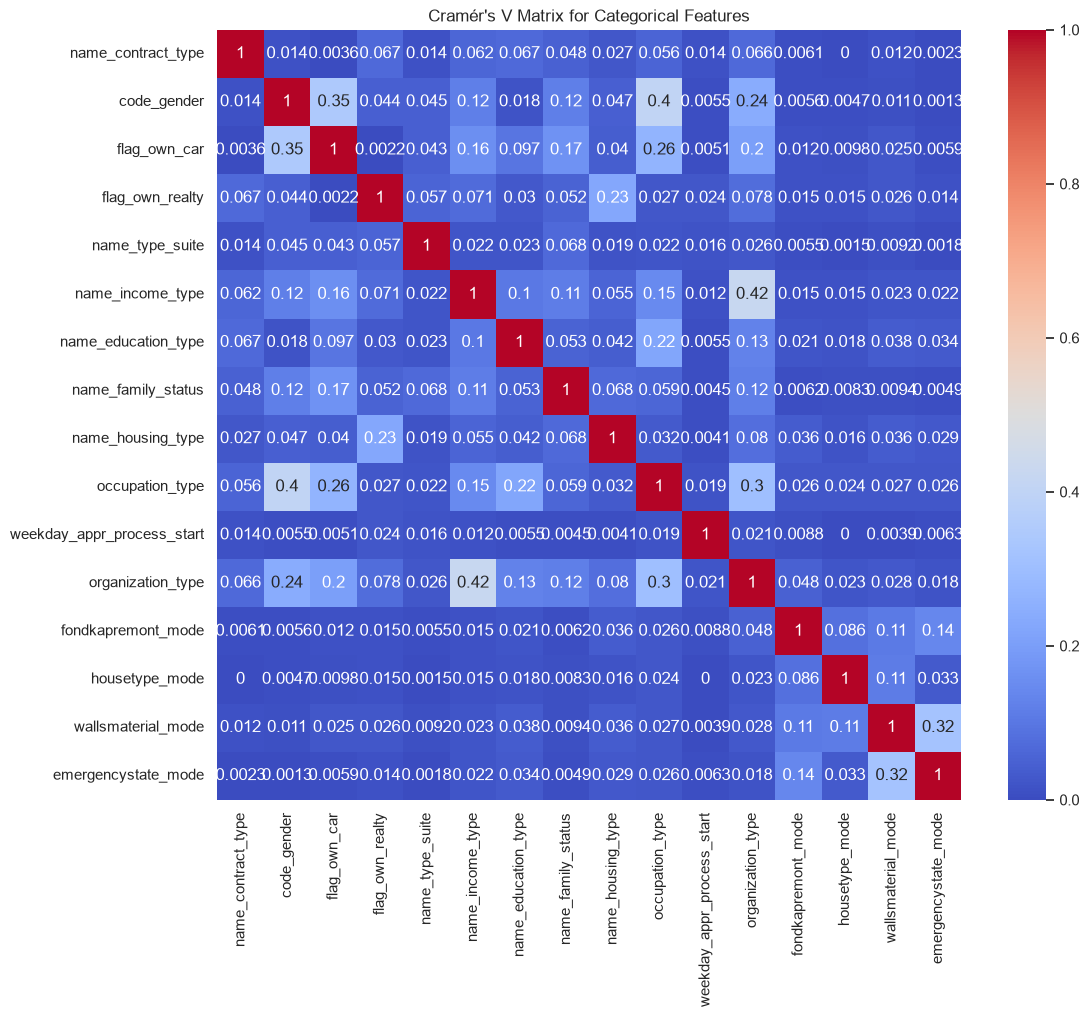

In [178]:
def cramers_v(x, y):
    """
    Compute bias-corrected Cramér's V statistic for two categorical variables.
    """
    confusion_matrix = pd.crosstab(x, y)

    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()

    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))


cramers_matrix = pd.DataFrame(
    np.zeros((len(cat_ds.columns), len(cat_ds.columns))),
    index=cat_ds.columns,
    columns=cat_ds.columns
)

for col1 in cat_ds.columns:
    for col2 in cat_ds.columns:
        cramers_matrix.loc[col1, col2] = cramers_v(
            cat_ds[col1],
            cat_ds[col2]
        )

plt.figure(figsize=(12, 10))

sns.heatmap(
    cramers_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=0,
    vmax=1
)

plt.title("Cramér's V Matrix for Categorical Features")
plt.savefig("Correlation of categorical variables.png")
plt.show()


##### Discussion

No high-correlation relaitonships are found. This means that there are no overlapping features among the categorical ones.

### Explore missing values

In [179]:
missing = pd.DataFrame({
    'Missing Values': ds.isna().sum(),
    'Percentage': (ds.isna().mean() * 100).round(2)
})

missing = missing[missing['Missing Values'] > 0]
missing = missing.sort_values('Percentage', ascending=False)

print(missing)

                          Missing Values  Percentage
commonarea_medi                   214865       69.87
commonarea_mode                   214865       69.87
commonarea_avg                    214865       69.87
nonlivingapartments_mode          213514       69.43
nonlivingapartments_medi          213514       69.43
...                                  ...         ...
ext_source_2                         660        0.21
amt_goods_price                      278        0.09
amt_annuity                           12        0.00
cnt_fam_members                        2        0.00
days_last_phone_change                 1        0.00

[67 rows x 2 columns]


In [180]:
# Show number of features with missing values proportion above a threshold 
for percentage in [30, 40, 50, 60]:
    print(f'{missing[missing['Percentage']> percentage].shape[0]} features with more than {percentage}% missing values')

50 features with more than 30% missing values
49 features with more than 40% missing values
41 features with more than 50% missing values
17 features with more than 60% missing values


#### Discussion 
At first glance the variables with highest proportion of missing values (almost 70%) are related to the real estate of the customer. 

In [181]:
missing[missing['Percentage']> 50].index

Index(['commonarea_medi', 'commonarea_mode', 'commonarea_avg',
       'nonlivingapartments_mode', 'nonlivingapartments_medi',
       'nonlivingapartments_avg', 'fondkapremont_mode', 'livingapartments_avg',
       'livingapartments_medi', 'livingapartments_mode', 'floorsmin_medi',
       'floorsmin_mode', 'floorsmin_avg', 'years_build_mode',
       'years_build_medi', 'years_build_avg', 'own_car_age', 'landarea_avg',
       'landarea_medi', 'landarea_mode', 'basementarea_mode',
       'basementarea_medi', 'basementarea_avg', 'ext_source_1',
       'nonlivingarea_medi', 'nonlivingarea_avg', 'nonlivingarea_mode',
       'elevators_medi', 'elevators_mode', 'elevators_avg',
       'wallsmaterial_mode', 'apartments_avg', 'apartments_medi',
       'apartments_mode', 'entrances_mode', 'entrances_medi', 'entrances_avg',
       'livingarea_avg', 'livingarea_mode', 'livingarea_medi',
       'housetype_mode'],
      dtype='str')

In [182]:
ds.fondkapremont_mode.value_counts(dropna=False)

fondkapremont_mode
NaN                      210295
reg oper account          73830
reg oper spec account     12080
not specified              5687
org spec account           5619
Name: count, dtype: int64

In [183]:
non_corrable_cols = [
    'housetype_mode', 
    'fondkapremont_mode',
    'wallsmaterial_mode',
    'emergencystate_mode'
]

building_cols = [
    col for col in ds.columns
    if col.endswith("_avg") or col.endswith("_medi") or col.endswith("_mode") and col not in non_corrable_cols
]
building_cols

['apartments_avg',
 'basementarea_avg',
 'years_beginexpluatation_avg',
 'years_build_avg',
 'commonarea_avg',
 'elevators_avg',
 'entrances_avg',
 'floorsmax_avg',
 'floorsmin_avg',
 'landarea_avg',
 'livingapartments_avg',
 'livingarea_avg',
 'nonlivingapartments_avg',
 'nonlivingarea_avg',
 'apartments_mode',
 'basementarea_mode',
 'years_beginexpluatation_mode',
 'years_build_mode',
 'commonarea_mode',
 'elevators_mode',
 'entrances_mode',
 'floorsmax_mode',
 'floorsmin_mode',
 'landarea_mode',
 'livingapartments_mode',
 'livingarea_mode',
 'nonlivingapartments_mode',
 'nonlivingarea_mode',
 'apartments_medi',
 'basementarea_medi',
 'years_beginexpluatation_medi',
 'years_build_medi',
 'commonarea_medi',
 'elevators_medi',
 'entrances_medi',
 'floorsmax_medi',
 'floorsmin_medi',
 'landarea_medi',
 'livingapartments_medi',
 'livingarea_medi',
 'nonlivingapartments_medi',
 'nonlivingarea_medi',
 'totalarea_mode']

In [184]:
ds[['housetype_mode',
 'wallsmaterial_mode',
 'emergencystate_mode']]

,housetype_mode,wallsmaterial_mode,emergencystate_mode
0,block of flats,"Stone, brick",No
1,block of flats,Block,No
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
...,...,...,...
307506,block of flats,"Stone, brick",No
307507,block of flats,"Stone, brick",No
307508,block of flats,Panel,No
307509,block of flats,"Stone, brick",No


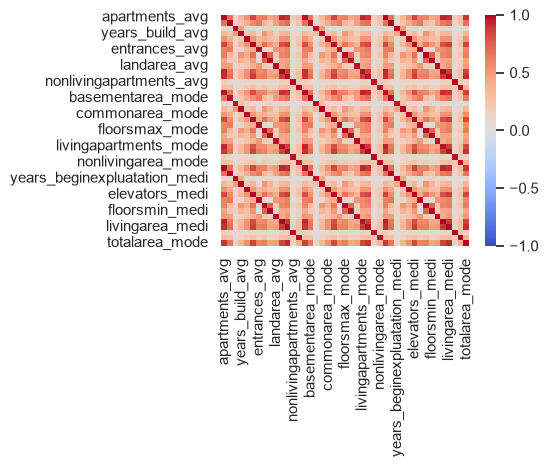

In [185]:
corr = ds[building_cols].corr()

plt.figure(figsize=(4, 3))
sns.heatmap(corr, annot=False, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

In [186]:
# Look at only those pairs with correlation above |0.7|

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr = (
    upper.stack()
         .reset_index()
         .rename(columns={
             "level_0": "Feature 1",
             "level_1": "Feature 2",
             0: "Correlation"
         })
)

high_corr_0_7 = high_corr[high_corr["Correlation"].abs() > 0.7]

print(high_corr_0_7.sort_values("Correlation", ascending=False))

           Feature 1         Feature 2  Correlation
160  years_build_avg  years_build_medi     0.998495
380    floorsmin_avg    floorsmin_medi     0.997241
336    floorsmax_avg    floorsmax_medi     0.997034
292    entrances_avg    entrances_medi     0.996886
248    elevators_avg    elevators_medi     0.996099
..               ...               ...          ...
939   floorsmax_mode    floorsmin_medi     0.729871
365    floorsmin_avg    floorsmax_mode     0.729179
925   floorsmax_mode    floorsmin_mode     0.726334
981   floorsmin_mode    floorsmax_medi     0.722970
323    floorsmax_avg    floorsmin_mode     0.722243

[117 rows x 3 columns]


In [187]:
high_corr.shape

(1849, 3)

#### Next step

It could be assumed that the three variables for each characteristic (the variables end with _mode, _avg and _medi, respectively) are highly correlated with each other. Depending on how high their correlation is, they may be even considered redundant.   
Thus, the correlation value will be calculated and the smallest correlation value amongst each triplet will be outputted. 

In [188]:
'''This code checks the smallest correlation within each triplet of variables.'''

# Get the base names (e.g. "elevators", "commonarea", ...)
bases = sorted({
    col.rsplit("_", 1)[0]
    for col in building_cols
})

results = []

for base in bases:
    cols = [
        f"{base}_avg",
        f"{base}_medi",
        f"{base}_mode"
    ]

    # Skip incomplete groups
    if not all(col in ds.columns for col in cols):
        continue

    # Correlation matrix for the three variables
    corr = ds[cols].corr()

    # Extract the three pairwise correlations
    pairwise_corrs = [
        corr.loc[c1, c2]
        for c1, c2 in itertools.combinations(cols, 2)
    ]

    results.append({
        "Characteristic": base,
        "Minimum correlation": min(pairwise_corrs)
    })

results = pd.DataFrame(results).sort_values(
    "Minimum correlation"
)

print(results)


             Characteristic  Minimum correlation
12  years_beginexpluatation             0.963539
11            nonlivingarea             0.966087
10      nonlivingapartments             0.969370
8          livingapartments             0.970117
9                livingarea             0.972050
0                apartments             0.973259
1              basementarea             0.973496
7                  landarea             0.973696
2                commonarea             0.977147
4                 entrances             0.977743
3                 elevators             0.978837
5                 floorsmax             0.985689
6                 floorsmin             0.985875
13              years_build             0.989444


In [189]:
results.to_excel('min_corr_real_estate_features.xlsx')

In [190]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


##### Discussion and Decision 
The above code snippet shows extremely high correlation (at least 0.96) between the variables of one triplet. This means that having a triplet is not neccesary and thus only on the variables will be left. The variable to be left is the one which ends with _avg, since it is defined as the normalized average value.  
The variable left will be later imputed in a meaningul matter, perhaps with an average (or some sort of kNN imputation). 

In [191]:
#Create a copy of ds which will be left as an older version
ds_old = ds.copy()

In [192]:
ds_old

,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,amt_goods_price,...,flag_document_18,flag_document_19,flag_document_20,flag_document_21,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year
0,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,225000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,225000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,585000.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,319500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [193]:
characteristics_to_drop = results['Characteristic'].tolist()

In [194]:
characteristics_to_drop

['years_beginexpluatation',
 'nonlivingarea',
 'nonlivingapartments',
 'livingapartments',
 'livingarea',
 'apartments',
 'basementarea',
 'landarea',
 'commonarea',
 'entrances',
 'elevators',
 'floorsmax',
 'floorsmin',
 'years_build']

In [195]:
cols_to_drop = []

for c in characteristics_to_drop:
    cols_to_drop.extend([f"{c}_medi", f"{c}_mode"])

ds = ds.drop(columns=cols_to_drop)


In [196]:
ds.shape

(307511, 93)

In [197]:
# Check number of missing values again 
missing_new = pd.DataFrame({
    'Missing Values': ds.isna().sum(),
    'Percentage': (ds.isna().mean() * 100).round(2)
})

missing_new = missing_new[missing_new['Missing Values'] > 0]
missing_new = missing_new.sort_values('Percentage', ascending=False)

print(missing_new)

                             Missing Values  Percentage
commonarea_avg                       214865       69.87
nonlivingapartments_avg              213514       69.43
fondkapremont_mode                   210295       68.39
livingapartments_avg                 210199       68.35
floorsmin_avg                        208642       67.85
years_build_avg                      204488       66.50
own_car_age                          202929       65.99
landarea_avg                         182590       59.38
basementarea_avg                     179943       58.52
ext_source_1                         173378       56.38
nonlivingarea_avg                    169682       55.18
elevators_avg                        163891       53.30
wallsmaterial_mode                   156341       50.84
apartments_avg                       156061       50.75
entrances_avg                        154828       50.35
livingarea_avg                       154350       50.19
housetype_mode                       154297     

In [198]:
# Show number of features with missing values proportion above a threshold 
for percentage in [30, 40, 50, 60]:
    print(f'{missing_new[missing_new['Percentage']> percentage].shape[0]} features with more than {percentage}% missing values')

22 features with more than 30% missing values
21 features with more than 40% missing values
17 features with more than 50% missing values
7 features with more than 60% missing values


#### Next steps 

Introduce a flag variable such as [variable_name]_missing for each missing variable and impute the variable with something meaningful like a mean.  
Discuss why two dataset will not be created - because i want to train all algorithms on the very same dataset.

In [199]:
# Create a list containing every variable with approximately 20% or more missing variables
high_missing_vars = missing_new[missing_new['Percentage']> 19].index.tolist()    # 19 is chosen so as to capture ext_source_3

In [200]:
high_missing_vars

['commonarea_avg',
 'nonlivingapartments_avg',
 'fondkapremont_mode',
 'livingapartments_avg',
 'floorsmin_avg',
 'years_build_avg',
 'own_car_age',
 'landarea_avg',
 'basementarea_avg',
 'ext_source_1',
 'nonlivingarea_avg',
 'elevators_avg',
 'wallsmaterial_mode',
 'apartments_avg',
 'entrances_avg',
 'livingarea_avg',
 'housetype_mode',
 'floorsmax_avg',
 'years_beginexpluatation_avg',
 'totalarea_mode',
 'emergencystate_mode',
 'occupation_type',
 'ext_source_3']

In [201]:
# Introduce flag variables and impute numeric variables  
# Categorical variables to be imputed after encoding 

for col in high_missing_vars:
    # Create missing flag
    ds[f"{col}_missing"] = ds[col].isna().astype(int)

In [202]:
ds.shape

(307511, 116)

In [203]:
# Check number of missing values again 
missing_new_2 = pd.DataFrame({
    'Missing Values': ds.isna().sum(),
    'Percentage': (ds.isna().mean() * 100).round(2)
})

missing_new_2 = missing_new_2[missing_new_2['Missing Values'] > 0]
missing_new_2 = missing_new_2.sort_values('Percentage', ascending=False)

print(missing_new_2)

                             Missing Values  Percentage
commonarea_avg                       214865       69.87
nonlivingapartments_avg              213514       69.43
fondkapremont_mode                   210295       68.39
livingapartments_avg                 210199       68.35
floorsmin_avg                        208642       67.85
years_build_avg                      204488       66.50
own_car_age                          202929       65.99
landarea_avg                         182590       59.38
basementarea_avg                     179943       58.52
ext_source_1                         173378       56.38
nonlivingarea_avg                    169682       55.18
elevators_avg                        163891       53.30
wallsmaterial_mode                   156341       50.84
apartments_avg                       156061       50.75
entrances_avg                        154828       50.35
livingarea_avg                       154350       50.19
housetype_mode                       154297     

In [204]:
# Check number of missing values again 
missing_new_3 = pd.DataFrame({
    'Missing Values': ds.isna().sum(),
    'Percentage': (ds.isna().mean() * 100).round(2)
})

missing_new_3 = missing_new_3[missing_new_3['Missing Values'] > 0]
missing_new_3 = missing_new_3.sort_values('Percentage', ascending=False)

print(missing_new_3)

                             Missing Values  Percentage
commonarea_avg                       214865       69.87
nonlivingapartments_avg              213514       69.43
fondkapremont_mode                   210295       68.39
livingapartments_avg                 210199       68.35
floorsmin_avg                        208642       67.85
years_build_avg                      204488       66.50
own_car_age                          202929       65.99
landarea_avg                         182590       59.38
basementarea_avg                     179943       58.52
ext_source_1                         173378       56.38
nonlivingarea_avg                    169682       55.18
elevators_avg                        163891       53.30
wallsmaterial_mode                   156341       50.84
apartments_avg                       156061       50.75
entrances_avg                        154828       50.35
livingarea_avg                       154350       50.19
housetype_mode                       154297     

### EDA on the rest of the variables
Manually inspect some of the variables with values looking suspicious.

In [205]:
ds.describe().transpose().to_csv('eda_rest_of_variables.csv')

#### Variables looking suspicious 
After inspection of the .csv file in Excel, following variables are considered suspicious (reason is in parenthesis):  
- cnt_children (max value is 19)
- days_employed (both pos and neg values; max value is 365243)
- own_car_age (max value 91)
- cnt_fam_members (max value is 20)
- amt_req_credit_bureau_qrt (max value is 261)

##### Inspetion of cnt_children

In [206]:
ds.cnt_children.value_counts()

cnt_children
0     215371
1      61119
2      26749
3       3717
4        429
5         84
6         21
7          7
14         3
8          2
9          2
12         2
10         2
19         2
11         1
Name: count, dtype: int64

In [207]:
# Show the gender of the applicant with extreme number of children 
ds[ds['cnt_children'] > 7][['code_gender', 'cnt_children']]

,code_gender,cnt_children
12615,M,8
23881,F,9
34545,M,11
80948,F,12
132585,F,10
154317,F,8
155369,F,19
171125,F,12
176011,M,14
183878,F,14


##### Decision about cnt_children
All extreme values were plotted against the gender of the applicant. Theoretically, it is possible for a men to have 19 children, but it is highly unlikely for a woman to hae born 19 children. Since most of the "extreme" applications belong to women, all values of the variable cnt_children, which are 10 and above will be replaced by the mode value of the variable.

In [208]:
mode_value_chld = ds['cnt_children'].mode()[0]

ds.loc[ds['cnt_children'] > 10, 'cnt_children'] = mode_value_chld

##### Inspection of days_employed 

In [209]:
ds.days_employed.describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: days_employed, dtype: float64

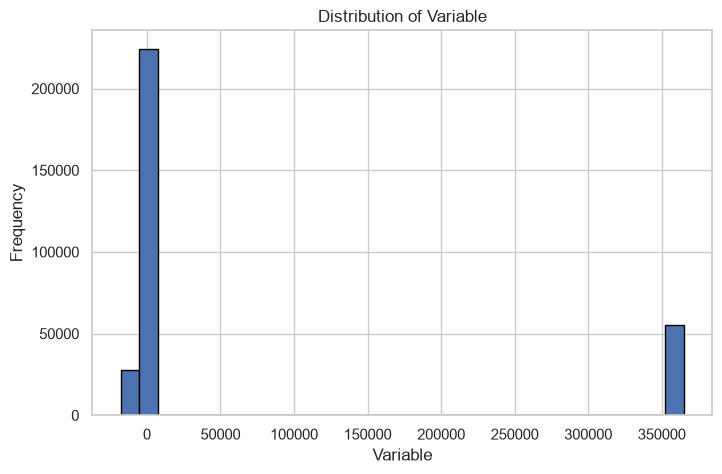

In [210]:
plt.figure(figsize=(8, 5))
plt.hist(ds["days_employed"], bins=30, edgecolor="black")

plt.title("Distribution of Variable")
plt.xlabel("Variable")
plt.ylabel("Frequency")

plt.show()

In [211]:
ds.days_employed.value_counts()

days_employed
 365243    55374
-200         156
-224         152
-199         151
-230         151
           ...  
-12316         1
-11100         1
-12971         1
-11084         1
-8694          1
Name: count, Length: 12574, dtype: int64

There is an impossible value of 365243 which corresponds to approximately 1000 years, but exists more than 55 000 times. Thus, it must be a placeholder, maybe for a missing value. This will now be checked. 

In [212]:
# An older version of the dataset is intentionally used because name_income_type was already broken down during encoding 
ds.loc[
    ds["days_employed"] == 365243,
    "name_income_type"
].value_counts()

name_income_type
Pensioner     55352
Unemployed       22
Name: count, dtype: int64

#### Decision for days_employed
Even though most of the variables correspond to pensioners, the employment time can not be estimated with certainty. Therefore, flag variable will be created for the anomaly values. These values will be then be replaced with NaNs and later encoded.

In [213]:
ds['days_employed_anomaly'] = (ds['days_employed'] == 365243).astype(int)
ds['days_employed'] = ds['days_employed'].replace(365243, np.nan)

C:\Users\user\AppData\Local\Temp\ipykernel_25836\3176028868.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ds['days_employed_anomaly'] = (ds['days_employed'] == 365243).astype(int)


#### Inspection of  own_car_age

In [214]:
ds['own_car_age'][ds['own_car_age']>25].value_counts(ascending=True)

own_car_age
48.0       1
56.0       1
57.0       1
69.0       1
50.0       1
47.0       1
52.0       1
63.0       2
91.0       2
51.0       3
55.0       4
46.0       5
49.0       6
45.0      11
54.0      12
43.0      19
44.0      21
42.0      42
41.0      58
37.0      75
39.0      78
40.0      85
38.0      97
36.0     124
33.0     132
35.0     157
34.0     183
32.0     208
31.0     267
30.0     326
29.0     397
27.0     483
28.0     542
26.0     580
65.0     891
64.0    2443
Name: count, dtype: int64

#### Decision for own_car_age 
Even though a 91 year-old car seems way too old, it is by far not impossible. On the contrary, it may actually be evidence of the well-being of the applicant because such a car most probably a high collectionist value.  
Nothing will be changed in this variable at this point. 

#### Inspection of cnt_family_members

In [215]:
ds.cnt_fam_members.value_counts()

cnt_fam_members
2.0     158357
1.0      67847
3.0      52601
4.0      24697
5.0       3478
6.0        408
7.0         81
8.0         20
9.0          6
10.0         3
14.0         2
12.0         2
20.0         2
16.0         2
13.0         1
15.0         1
11.0         1
Name: count, dtype: int64

#### Decision for cnt_fam_members 
Extreme values (above 10) are very rare. Moreover, they can not be neccesarily treated as a wrong input due to the unknown definition of a 'family member'. For these reasons, nothing will be changed in the column for the moment.

#### Inspection of amt_req_credit_bureau_qrt

In [216]:
ds.amt_req_credit_bureau_qrt.value_counts()

amt_req_credit_bureau_qrt
0.0      215417
1.0       33862
2.0       14412
3.0        1717
4.0         476
5.0          64
6.0          28
8.0           7
7.0           7
261.0         1
19.0          1
Name: count, dtype: int64

#### Decision for amt_req_credit_bureau_qrt 
Obviously, the value of 261 is an outlier - not only for mathematical, but also for logical reasons. It is hardly imaginable that the number of enquiries to Credit Bureau about the client 3 month before application (excluding one month before application) can be 261.  
The value of 19 is also an outlier, which can negatively influence future scaling.  
Thus, both values will be replaced by the mode of the variable.

In [217]:
mode_value = ds["amt_req_credit_bureau_qrt"].mode()[0]

ds.loc[ds["amt_req_credit_bureau_qrt"].isin([261, 19]), "amt_req_credit_bureau_qrt"] = mode_value

### Check correlations 

In [218]:
numeric_ds = ds.select_dtypes(include=['number'])
cat_ds = ds.select_dtypes(include=['object'])

C:\Users\user\AppData\Local\Temp\ipykernel_25836\3508541583.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_ds = ds.select_dtypes(include=['object'])


In [219]:
correlation_matrix = numeric_ds.corr(method="pearson")

# Keep only the upper triangle of the matrix
upper = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# Display pairs with |correlation| > 0.8
high_corr = (
    upper.stack()
         .reset_index()
         .rename(columns={"level_0": "Feature 1",
                          "level_1": "Feature 2",
                          0: "Correlation"})
)

high_corr = high_corr[high_corr["Correlation"].abs() > 0.8]
high_corr = high_corr.sort_values(by="Correlation", key=abs, ascending=False)

print(high_corr)
high_corr.to_csv("High Correlation Pairs updated.csv")

                                Feature 1  \
1413                       flag_emp_phone   
4694             obs_30_cnt_social_circle   
9691  years_beginexpluatation_avg_missing   
308                            amt_credit   
9285                entrances_avg_missing   
...                                   ...   
8576                 landarea_avg_missing   
8680             basementarea_avg_missing   
8681             basementarea_avg_missing   
3677                        elevators_avg   
8579                 landarea_avg_missing   

                                Feature 2  Correlation  
1413                days_employed_anomaly    -0.999868  
4694             obs_60_cnt_social_circle     0.998490  
9691               totalarea_mode_missing     0.987385  
308                       amt_goods_price     0.986968  
9285                floorsmax_avg_missing     0.984628  
...                                   ...          ...  
8576               livingarea_avg_missing     0.818916  
868

#### Observation
Obviously, most of the pairs contain only some of the newly created _missing variables. For this reason, the correlation between these variables will now be visualized

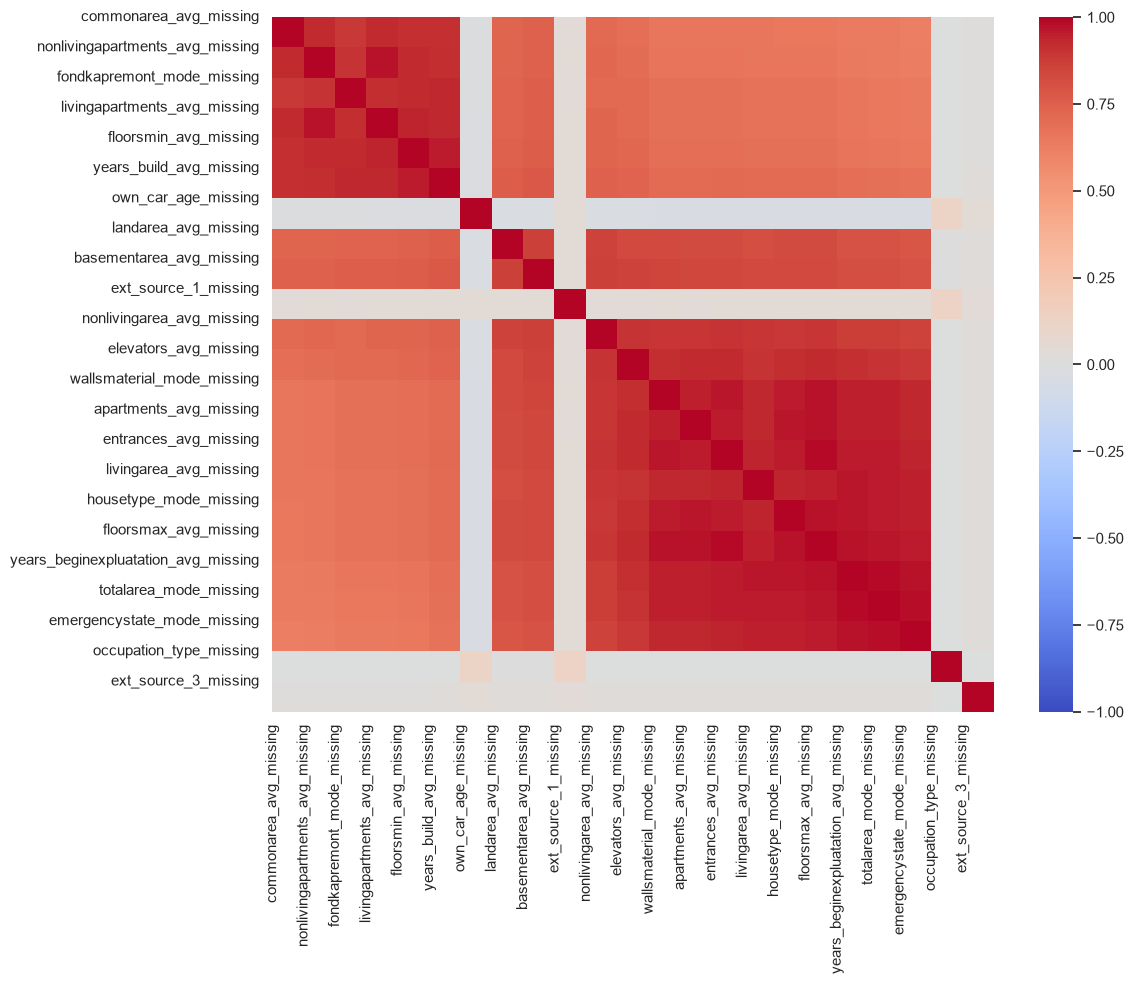

In [220]:
# Check correlations of the _missing variables 

missing_flags = [col for col in ds.columns if col.endswith("_missing")]
corr_vars_missing = ds[missing_flags].corr()


plt.figure(figsize=(12, 10))
ax = sns.heatmap(
    corr_vars_missing, 
    annot=False, 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1
)

# Force matplotlib to display ALL labels along both axes
ax.set_xticks(range(len(corr_vars_missing.columns)))
ax.set_yticks(range(len(corr_vars_missing.columns)))

ax.set_xticklabels(corr_vars_missing.columns, rotation=90)
ax.set_yticklabels(corr_vars_missing.columns, rotation=0)

plt.tight_layout()
plt.savefig('Correlation between _missing vars.png')
plt.show()



In [221]:
stophere

NameError: name 'stophere' is not defined

#### Analysis
As it can be seen, the only variables which are not very high correlated are own_car_age_missing, ext_source_1_missing, ext_source_3_missing and occupation_type_missing. THe other variables, which all are characteristics of the residential place of the applicant, are with very high correlation between them.  

#### Next step
The current problem has two sides. The first one is that these features (the ones discussed above, except for the 4 explicitly listed) are redundant and they will distort the model if not treated properly.  
The other one is that the missingness they are indicating is important. One potential solution could be to "combine" them in one flag variable with a name like "all_residential_vars_missing". However, if this variable is equal to 1, then the model can't know whether the applicant didn't fill out just one of the variables or all of them. This is an unacceptable loss of information.  
Alternatively, a variable can be created, which counts the number of residential variables that are missing (called num_building_vars_missing). In this case, the model will still be able to differentiate whether an applicant left one of all of the variables empty. Of coure, some information will still be lost because it will not be known which exactly variable(s) is (are) missing, but since they are so highly correlated, it can be argued that they carry similar information. More important is how many are missing and not which precisely are missing since most of them are simultanuously missing anyway.  
After num_building_vars_missing is created, the highly correlated _missing columns which refer to the residential building will be dropped.

In [ ]:
missing_flags

['commonarea_avg_missing',
 'nonlivingapartments_avg_missing',
 'fondkapremont_mode_missing',
 'livingapartments_avg_missing',
 'floorsmin_avg_missing',
 'years_build_avg_missing',
 'own_car_age_missing',
 'landarea_avg_missing',
 'basementarea_avg_missing',
 'ext_source_1_missing',
 'nonlivingarea_avg_missing',
 'elevators_avg_missing',
 'wallsmaterial_mode_missing',
 'apartments_avg_missing',
 'entrances_avg_missing',
 'livingarea_avg_missing',
 'housetype_mode_missing',
 'floorsmax_avg_missing',
 'years_beginexpluatation_avg_missing',
 'totalarea_mode_missing',
 'emergencystate_mode_missing',
 'occupation_type_missing',
 'ext_source_3_missing']

In [ ]:
# Create a list of the redundant _missing variables (own_car_age_missing, ext_source_1_missing, ext_source_3_missing and occupation_type_missing are left since they are not correlated)
exclude = {'own_car_age_missing', 'ext_source_1_missing', 'ext_source_3_missing', 'occupation_type_missing'}

redundant_vars = [col for col in missing_flags if col not in exclude]

In [ ]:
redundant_vars

['commonarea_avg_missing',
 'nonlivingapartments_avg_missing',
 'fondkapremont_mode_missing',
 'livingapartments_avg_missing',
 'floorsmin_avg_missing',
 'years_build_avg_missing',
 'landarea_avg_missing',
 'basementarea_avg_missing',
 'nonlivingarea_avg_missing',
 'elevators_avg_missing',
 'wallsmaterial_mode_missing',
 'apartments_avg_missing',
 'entrances_avg_missing',
 'livingarea_avg_missing',
 'housetype_mode_missing',
 'floorsmax_avg_missing',
 'years_beginexpluatation_avg_missing',
 'totalarea_mode_missing',
 'emergencystate_mode_missing']

In [ ]:
# Create a new instance of the dataset with the same name and leave the other one as a back-up copy

ds_old_0_5 = ds.copy() #0.5 is smaller than 1, so ds_old_0_5 is a newer version than ds_old

In [ ]:
ds_old_0_5.shape

(307511, 117)

In [ ]:
# Create the variable num_building_vars_missing

# Sum the values of the _missing columns (since they are binary, so are they counted)
ds['num_building_vars_missing'] = ds[redundant_vars].sum(axis=1)

# 3. Drop the individual high-correlation _missing flags to eliminate multicollinearity
ds = ds.drop(columns=redundant_vars)

C:\Users\user\AppData\Local\Temp\ipykernel_25836\3257181390.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ds['num_building_vars_missing'] = ds[redundant_vars].sum(axis=1)


In [ ]:
ds.shape

(307511, 99)

In [ ]:
# Check correlations again 
# Suffix _n is added since this is the n-th iteration

numeric_ds_n = ds.select_dtypes(include=['number'])

correlation_matrix_n = numeric_ds_n.corr(method="pearson")

# Keep only the upper triangle of the matrix
upper_n = correlation_matrix_n.where(
    np.triu(np.ones(correlation_matrix_n.shape), k=1).astype(bool)
)

# Display pairs with |correlation| > 0.8
high_corr_n = (
    upper_n.stack()
         .reset_index()
         .rename(columns={"level_0": "Feature 1",
                          "level_1": "Feature 2",
                          0: "Correlation"})
)

high_corr_n = high_corr_n[high_corr_n["Correlation"].abs() > 0.8]
high_corr_n = high_corr_n.sort_values(by="Correlation", key=abs, ascending=False)

print(high_corr_n)
high_corr_n.to_csv("High Correlation_N Pairs.csv")

                       Feature 1                    Feature 2  Correlation
1160              flag_emp_phone        days_employed_anomaly    -0.999868
3866    obs_30_cnt_social_circle     obs_60_cnt_social_circle     0.998490
254                   amt_credit              amt_goods_price     0.986968
1597        region_rating_client  region_rating_client_w_city     0.950842
2614              apartments_avg         livingapartments_avg     0.943952
3531              livingarea_avg               totalarea_mode     0.925039
2615              apartments_avg               livingarea_avg     0.913619
2618              apartments_avg               totalarea_mode     0.892627
3445        livingapartments_avg               livingarea_avg     0.880798
101                 cnt_children              cnt_fam_members     0.875446
3030               elevators_avg               livingarea_avg     0.867776
1933  reg_region_not_work_region  live_region_not_work_region     0.860627
3950    def_30_cnt_social

#### Next steps 
The rest of the pairs above will now be tackled 

#### Discussion about several pairs 
1. flag_emp_phone and days_employed_anomaly are with almost perfect negative correlation. It waa already determined that anomaly values of days_employed (i.e. where days_employed_anomaly = 1) belong to pensioners. Thus, it perfectly makes sense that they have not provided an employer's phone. Since both variables capture merely the same thing and flag_emp_phone does not bring significantly more information than to signalize a pensioner, flag_emp_phone can be dropped. (Note: the variable name_income_type does include categories like 'unemployed' and 'student', for which the absence of employer's phone is also self-explanatory, so flag_emp_phone is not useful fot them either)
2. obs_30_cnt_social_circle and obs_60_cnt_social_circle both refer to the number of observations "of client's social surroundings with observable 30 DPD (days past due) default" and 60 DPD, respectively. In light of their almost perfect positive correlation, one of them will be dropped. Perhaps the feature comprising a longer time interval could carry more important information from a business perspective, so the feature to be dropped is obs_30_cnt_social_circle.  
Analogously, def_30_cnt_social_circle will be dropped and def_60_cnt_social_circle will be remain.
3. amt_credit and amt_goods_price refer to roughly the same thing with the small difference that amt_goods_price is the amount of credit given for consumer loans (it is actually the price of the goods for which the credit is given, but both are almost the same). Since amt_credit is the more general variable, amt_goods_price will be dropped.
4. region_rating_client and region_rating_client_w_city are both region ratings but the second one is "taking the city into account". Even though the difference from a business perspective is not clear, they are extremely high correlated, so the first feature (region_rating_client) will be dropped.
5. The variables apartments_avg, livingapartments_avg, livingarea_avg, totalarea_mode and elevators_avg exhibit pairwise high correlations. appartments_avg appears most times in the above pairs, so it will be the first one to drop. After correlations are computed again, more variables may be dropped.
6. The variables reg_region_not_work_region and live_region_not_work_region are both flag variables showing if the permanent (and contact, respectively) addresses match the working address. Since they are both showing incocsistency in the addresses given by the applicant adn also exhibit very high correlation, they can be merged into one binary variable called reg_or_liv_reg_not_work, where 1 will signify that EITHER of the addresses is different from the working one, while 0 will show that neither of them is different from the working one.
7. Similar to 6., reg_city_not_work_city and live_city_not_work_city are merged into one variable called reg_or_liv_city_not_work where 1 will signify that EITHER of the addresses is different from the working one, while 0 will show that neither of them is different from the working one.

In [ ]:
ds = ds.drop(columns=['flag_emp_phone', 'obs_30_cnt_social_circle', 'def_30_cnt_social_circle', 'amt_goods_price', 'region_rating_client', 'apartments_avg'])

In [ ]:
# Create the variables in points 6 and 7

ds['reg_or_liv_reg_not_work'] = ((ds.reg_region_not_work_region == 1) | (ds.live_region_not_work_region == 1)).astype(int)
ds['reg_or_liv_city_not_work'] = ((ds.reg_city_not_work_city == 1) | (ds.live_city_not_work_city == 1)).astype(int)

ds = ds.drop(columns=['reg_region_not_work_region', 'live_region_not_work_region', 'reg_city_not_work_city', 'live_city_not_work_city'])

#### Compute correlations again

In [ ]:
# Check correlations again 
# Suffix _n is added since this is the n-th iteration

numeric_ds_n_2 = ds.select_dtypes(include=['number'])

correlation_matrix_n_2 = numeric_ds_n_2.corr(method="pearson")

# Keep only the upper triangle of the matrix
upper_n_2 = correlation_matrix_n_2.where(
    np.triu(np.ones(correlation_matrix_n_2.shape), k=1).astype(bool)
)

# Display pairs with |correlation| > 0.8
high_corr_n_2 = (
    upper_n_2.stack()
         .reset_index()
         .rename(columns={"level_0": "Feature 1",
                          "level_1": "Feature 2",
                          0: "Correlation"})
)

high_corr_n_2 = high_corr_n_2[high_corr_n_2["Correlation"].abs() > 0.8]
high_corr_n_2 = high_corr_n_2.sort_values(by="Correlation", key=abs, ascending=False)

print(high_corr_n_2)
high_corr_n_2.to_csv("High Correlation_N Pairs.csv")

                 Feature 1             Feature 2  Correlation
2587        livingarea_avg        totalarea_mode     0.925039
2509  livingapartments_avg        livingarea_avg     0.880798
91            cnt_children       cnt_fam_members     0.875446
2134         elevators_avg        livingarea_avg     0.867776
2512  livingapartments_avg        totalarea_mode     0.848028
2137         elevators_avg        totalarea_mode     0.844628
2133         elevators_avg  livingapartments_avg     0.811786


In [ ]:
ds.totalarea_mode.value_counts()

totalarea_mode
0.0000    582
0.0570    247
0.0547    230
0.0550    227
0.0548    227
         ... 
0.6494      1
0.4952      1
0.4890      1
0.4820      1
0.7970      1
Name: count, Length: 5116, dtype: int64

#### Discussion and decision 

All variables in the above pairs are highly correlated, but they represent different characteristics and so dropping any of them might result in information loss. Since the number of pairs  (7) is small relative to the dataset shape, they will be left like that.

### Final check of dtypes 

In [ ]:
ds.dtypes 

target                       int64
name_contract_type             str
code_gender                    str
flag_own_car                   str
flag_own_realty                str
                             ...  
ext_source_3_missing         int64
days_employed_anomaly        int64
num_building_vars_missing    int64
reg_or_liv_reg_not_work      int64
reg_or_liv_city_not_work     int64
Length: 91, dtype: object

#### Observation
flag_own_car and flag_own_realty are str, but they must be binary numeric columns. They will now be changed. 

In [ ]:
ds['flag_own_car'] = ds['flag_own_car'].map({'N': 0, 'Y': 1}).astype('float64')
ds['flag_own_realty'] = ds['flag_own_realty'].map({'N': 0, 'Y': 1}).astype('float64')


In [ ]:
ds.shape

(307511, 91)

In [ ]:
ds.dtypes.value_counts()

int64      41
float64    36
str        14
Name: count, dtype: int64

### Create validation and testing datasets

In [ ]:
X_tr, X_test, y_tr, y_test = train_test_split(
    ds.drop(columns=["target"]),
    ds["target"],
    test_size=0.2,
    random_state=42,
    stratify=ds["target"]  # recommended for imbalanced datasets
)


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_tr, 
    y_tr, 
    test_size= 0.2,
    random_state= 12, 
    stratify=y_tr
)

### Imputation of numeric variables
An Imputer will be fitted to the training dataset and will then be used to modify both the training and test dataset

In [ ]:
numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()
print(len(numeric_cols))
numeric_cols



76


['flag_own_car',
 'flag_own_realty',
 'cnt_children',
 'amt_income_total',
 'amt_credit',
 'amt_annuity',
 'region_population_relative',
 'days_birth',
 'days_employed',
 'days_registration',
 'days_id_publish',
 'own_car_age',
 'flag_mobil',
 'flag_work_phone',
 'flag_cont_mobile',
 'flag_phone',
 'flag_email',
 'cnt_fam_members',
 'region_rating_client_w_city',
 'hour_appr_process_start',
 'reg_region_not_live_region',
 'reg_city_not_live_city',
 'ext_source_1',
 'ext_source_2',
 'ext_source_3',
 'basementarea_avg',
 'years_beginexpluatation_avg',
 'years_build_avg',
 'commonarea_avg',
 'elevators_avg',
 'entrances_avg',
 'floorsmax_avg',
 'floorsmin_avg',
 'landarea_avg',
 'livingapartments_avg',
 'livingarea_avg',
 'nonlivingapartments_avg',
 'nonlivingarea_avg',
 'totalarea_mode',
 'obs_60_cnt_social_circle',
 'def_60_cnt_social_circle',
 'days_last_phone_change',
 'flag_document_2',
 'flag_document_3',
 'flag_document_4',
 'flag_document_5',
 'flag_document_6',
 'flag_document_7'

In [ ]:
non_numeric_cols = X_train.select_dtypes(exclude=['number']).columns.tolist()
non_numeric_cols

['name_contract_type',
 'code_gender',
 'name_type_suite',
 'name_income_type',
 'name_education_type',
 'name_family_status',
 'name_housing_type',
 'occupation_type',
 'weekday_appr_process_start',
 'organization_type',
 'fondkapremont_mode',
 'housetype_mode',
 'wallsmaterial_mode',
 'emergencystate_mode']

In [ ]:
# Fit on training data
imputer = SimpleImputer(strategy="median")
imputer.fit(X_train[numeric_cols])

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](76,)","['flag_own_car','flag_own_realty','cnt_children',..., 'num_building_vars_missing','reg_or_liv_reg_not_work', 'reg_or_liv_city_not_work']"
indicator_ indicator_: :class:`~sklearn.impute.MissingIndicator`Indicator used to add binary indicators for missing values.`None` if `add_indicator=False`.,NoneType,None
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,76
"statistics_ statistics_: array of shape (n_features,)The imputation fill value for each feature.Computing statistics can result in `np.nan` values.During :meth:`transform`, features corresponding to `np.nan`statistics will be discarded.","ndarray[float64](76,)","[ 0., 1., 0.,...,12., 0., 0.]"


In [ ]:
# Transform all datasets
X_train[numeric_cols] = imputer.transform(X_train[numeric_cols])
X_val[numeric_cols] = imputer.transform(X_val[numeric_cols])
X_test[numeric_cols] = imputer.transform(X_test[numeric_cols])

### Treatment of missing values for non-numeric variables
All NaNs in the non-numeric columns with be filled with "Missing", so that the resulting dummy variable after OneHot encoding can have a meaningful name (alternatively, OneHot encoding could have handled the missing values automatically, but the resulting variable name will be a little less interpretable, which is not desired)

In [ ]:
X_train[non_numeric_cols] = X_train[non_numeric_cols].fillna("Missing")
X_val[non_numeric_cols]   = X_val[non_numeric_cols].fillna("Missing")
X_test[non_numeric_cols]  = X_test[non_numeric_cols].fillna("Missing")

In [ ]:
#Check if there are missing values left
print(X_train.isna().sum().sum())
print(X_val.isna().sum().sum())
print(X_test.isna().sum().sum())

0
0
0


### Encoding

All categorical variables will be one-hot encoded.

In [ ]:
categorical_cols = X_train.select_dtypes(include=['object', 'str']).columns.tolist()

In [ ]:
categorical_cols

['name_contract_type',
 'code_gender',
 'name_type_suite',
 'name_income_type',
 'name_education_type',
 'name_family_status',
 'name_housing_type',
 'occupation_type',
 'weekday_appr_process_start',
 'organization_type',
 'fondkapremont_mode',
 'housetype_mode',
 'wallsmaterial_mode',
 'emergencystate_mode']

In [ ]:
X_train.dtypes.value_counts()

float64    76
str        14
Name: count, dtype: int64

In [ ]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoder.fit(X_train[categorical_cols])   # Fit only on training

X_train_cat = encoder.transform(X_train[categorical_cols])
X_val_cat = encoder.transform(X_val[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

In [ ]:
# Convert the array back into a DataFrame with proper column names
X_cat_df = pd.DataFrame(
    X_train_cat, 
    columns=encoder.get_feature_names_out(categorical_cols), 
    index=X_train.index  # Keeps your original row index aligned
)

# Combine them: drop old categorical columns and add the new one-hot columns
X_train_encod = pd.concat([X_train.drop(columns=categorical_cols), X_cat_df], axis=1)

In [ ]:
X_train_cat.shape

(196806, 142)

In [ ]:
X_train_encod.shape

(196806, 218)

In [ ]:
X_train_encod.head()

,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,region_population_relative,days_birth,days_employed,days_registration,...,wallsmaterial_mode_Missing,wallsmaterial_mode_Mixed,wallsmaterial_mode_Monolithic,wallsmaterial_mode_Others,wallsmaterial_mode_Panel,"wallsmaterial_mode_Stone, brick",wallsmaterial_mode_Wooden,emergencystate_mode_Missing,emergencystate_mode_No,emergencystate_mode_Yes
168448,0.0,1.0,0.0,157500.0,1078200.0,38200.5,0.031329,-9697.0,-1003.0,-9685.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
214084,1.0,1.0,1.0,135000.0,323194.5,16632.0,0.020246,-17237.0,-3416.0,-8871.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
30400,1.0,1.0,0.0,270000.0,578979.0,29691.0,0.020713,-14410.0,-2273.0,-1992.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
280627,1.0,0.0,4.0,225000.0,900000.0,48955.5,0.014520,-14202.0,-476.0,-4146.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
97780,1.0,0.0,2.0,166500.0,180000.0,20308.5,0.003122,-10742.0,-3075.0,-402.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
# Convert encoded validation data to DataFrame
X_val_cat_df = pd.DataFrame(
    X_val_cat,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_val.index
)

# Replace original categorical columns
X_val_encod = pd.concat(
    [X_val.drop(columns=categorical_cols), X_val_cat_df],
    axis=1
)

In [ ]:
# Convert encoded test data to DataFrame
X_test_cat_df = pd.DataFrame(
    X_test_cat,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_test.index
)

# Replace original categorical columns
X_test_encod = pd.concat(
    [X_test.drop(columns=categorical_cols), X_test_cat_df],
    axis=1
)

In [ ]:
X_train_encod.keys()

Index(['flag_own_car', 'flag_own_realty', 'cnt_children', 'amt_income_total',
       'amt_credit', 'amt_annuity', 'region_population_relative', 'days_birth',
       'days_employed', 'days_registration',
       ...
       'wallsmaterial_mode_Missing', 'wallsmaterial_mode_Mixed',
       'wallsmaterial_mode_Monolithic', 'wallsmaterial_mode_Others',
       'wallsmaterial_mode_Panel', 'wallsmaterial_mode_Stone, brick',
       'wallsmaterial_mode_Wooden', 'emergencystate_mode_Missing',
       'emergencystate_mode_No', 'emergencystate_mode_Yes'],
      dtype='str', length=218)

### Separation of datasets for the needs of the models
Logistic Regression is the only model for which the variables are better to be scaled. All other models work just as good with non-scaled variables.  
For this reason, without sacrificing the fairness of the model comparison, separate train and test datasets will be created for LR and for the rest of the models.


In [ ]:
# Create copies of the encoded datasets 
# for training and testing for all models except for LR 
# (that's why it's called X_train_others and X_test_others)
X_train_others = X_train_encod.copy()
X_val_others = X_val_encod.copy()
X_test_others = X_test_encod.copy()

In [ ]:
# Create copies of validation and testing sets for clarity
y_train_others = y_train.copy()
y_val_others = y_val.copy()

In [ ]:
# Store as Parquet files 
X_train_others.to_parquet("X_train_others.parquet", engine='fastparquet')
X_test_others.to_parquet("X_test_others.parquet", engine='fastparquet') 
X_val_others.to_parquet("X_val_others.parquet", engine='fastparquet')

y_train_others.to_frame(name="y_train").to_parquet("y_train_others.parquet")
y_test.to_frame(name="y_test").to_parquet("y_test_others.parquet")
y_val_others.to_frame(name="y_val").to_parquet("y_val_others.parquet")

### Modify the datasets for LR

#### Methodology
The dataset will be scaled with StandardScaler due to the high range of some of the variables and, more importantly, their skewness.

In [ ]:
y_train 

168448    0
214084    0
30400     0
280627    0
97780     0
         ..
32370     0
301021    0
135784    0
204553    0
109970    0
Name: target, Length: 196806, dtype: int64

In [ ]:
s_scaler = StandardScaler()

X_train_lr = pd.DataFrame(
    s_scaler.fit_transform(X_train_encod),
    columns=X_train_encod.columns,
    index=X_train_encod.index
)

X_val_lr = pd.DataFrame(
    s_scaler.transform(X_val_encod),
    columns=X_val_encod.columns,
    index=X_val_encod.index
)

X_test_lr = pd.DataFrame(
    s_scaler.transform(X_test_encod),
    columns=X_test_encod.columns,
    index=X_test_encod.index
)

In [ ]:
# Store as Parquet files 
X_train_lr.to_parquet("X_train_lr.parquet", engine='fastparquet')
X_val_lr.to_parquet("X_val_lr.parquet", engine='fastparquet')
X_test_lr.to_parquet("X_test_lr.parquet", engine='fastparquet') 


In [ ]:
# Create copies of validation and testing sets for clarity
y_train_lr = y_train.copy()
y_val_lr = y_val.copy()


In [ ]:
y_train_lr.to_frame(name="y_train_lr").to_parquet("y_train_lr.parquet")
y_val_lr.to_frame(name="y_val_lr").to_parquet("y_val_lr.parquet")
y_test.to_frame(name="y_test").to_parquet("y_test_lr.parquet")

### Apply SMOTE to enhance the datasets and solve the class imbalance problem

In [ ]:
# Perform SMOTE oversampling on X_train_others and y_train for all models except for LR 
X_train_others_smote = X_train_others
y_train_others_smote = y_train_others

smote = SMOTE(random_state=42)
X_train_others_smote, y_train_others_smote = smote.fit_resample(X_train_others_smote, y_train_others_smote)


In [ ]:
# Perform SMOTE oversampling on X_train_lr and y_train for LR model 
X_train_lr_smote = X_train_lr
y_train_lr_smote = y_train_lr

smote = SMOTE(random_state=12)
X_train_lr_smote, y_train_lr_smote = smote.fit_resample(X_train_lr_smote, y_train_lr_smote)

In [ ]:
# Store as Parquet files 
X_train_others_smote.to_parquet("X_train_others_smote.parquet", engine='fastparquet')
y_train_others_smote.to_frame(name="y_train_others_smote").to_parquet("y_train_others_smote.parquet", engine='fastparquet')
X_train_lr_smote.to_parquet("X_train_lr_smote.parquet", engine='fastparquet')
y_train_lr_smote.to_frame(name="y_train_lr_smote").to_parquet("y_train_lr_smote.parquet", engine='fastparquet') 

### Note: 
The idea is to have both enhanced and non-enhaced with SMOTE datasets. Maybe I could train algorithms on both and see the differences and comment on them.